# Pothole detector - training on Colab

**Runtime -> Change runtime type -> T4 GPU.** Then Runtime -> Run all.

What happens: clone the repo, download the RDD2022 *India* subset from a Kaggle mirror
(~500 MB, no Kaggle login needed), keep only pothole boxes (class D40), fine-tune YOLOv8s,
and save `best.pt` to Google Drive.

Dataset: RDD2022 (Arya et al., 2022), India subset: 7,706 training images, 1,530 of them
contain potholes (3,187 boxes). The official `RDD2022_India.zip` link on the sekilab repo
returns 403 now, so we use the Kaggle mirror `musfequa/india-road-damage`, which has the
same folder layout (`India/train/images`, `India/train/annotations/xmls`).

In [1]:
!pip -q install ultralytics kagglehub
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE - change runtime type to GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00
GPU: Tesla T4


In [2]:
GITHUB_USER = 'HariOm297'
REPO = 'Pothole-Detection-System'
!rm -rf {REPO}
!git clone -q https://github.com/{GITHUB_USER}/{REPO}.git
%cd {REPO}

/content/Pothole-Detection-System


In [3]:
# Download RDD2022 India (Kaggle mirror, ~500 MB) and convert to YOLO format (potholes only)
import kagglehub, pathlib
RDD_INDIA = pathlib.Path(kagglehub.dataset_download('musfequa/india-road-damage')) / 'India'
print("dataset at:", RDD_INDIA)
!python scripts/rdd_to_yolo.py --src {RDD_INDIA} --out data/yolo
# expected: positives=1530 background=153 train=1431 val=252

100%|██████████| 503M/503M [00:26<00:00, 20.1MB/s]

Extracting files...


dataset at: /root/.cache/kagglehub/datasets/musfequa/india-road-damage/versions/1/India
positives=1530 background=153 train=1431 val=252


In [4]:
# ~45 min on a T4. If Colab disconnects, re-run with --epochs 40.
!python scripts/train.py --data data/yolo/data.yaml --model yolov8s.pt --epochs 60 --imgsz 640 --batch 16 --name pothole_v1

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo/data.yaml, degrees=3.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=Non

run dir: runs/detect/runs/pothole_v1
runs/detect/runs/pothole_v1/results.png


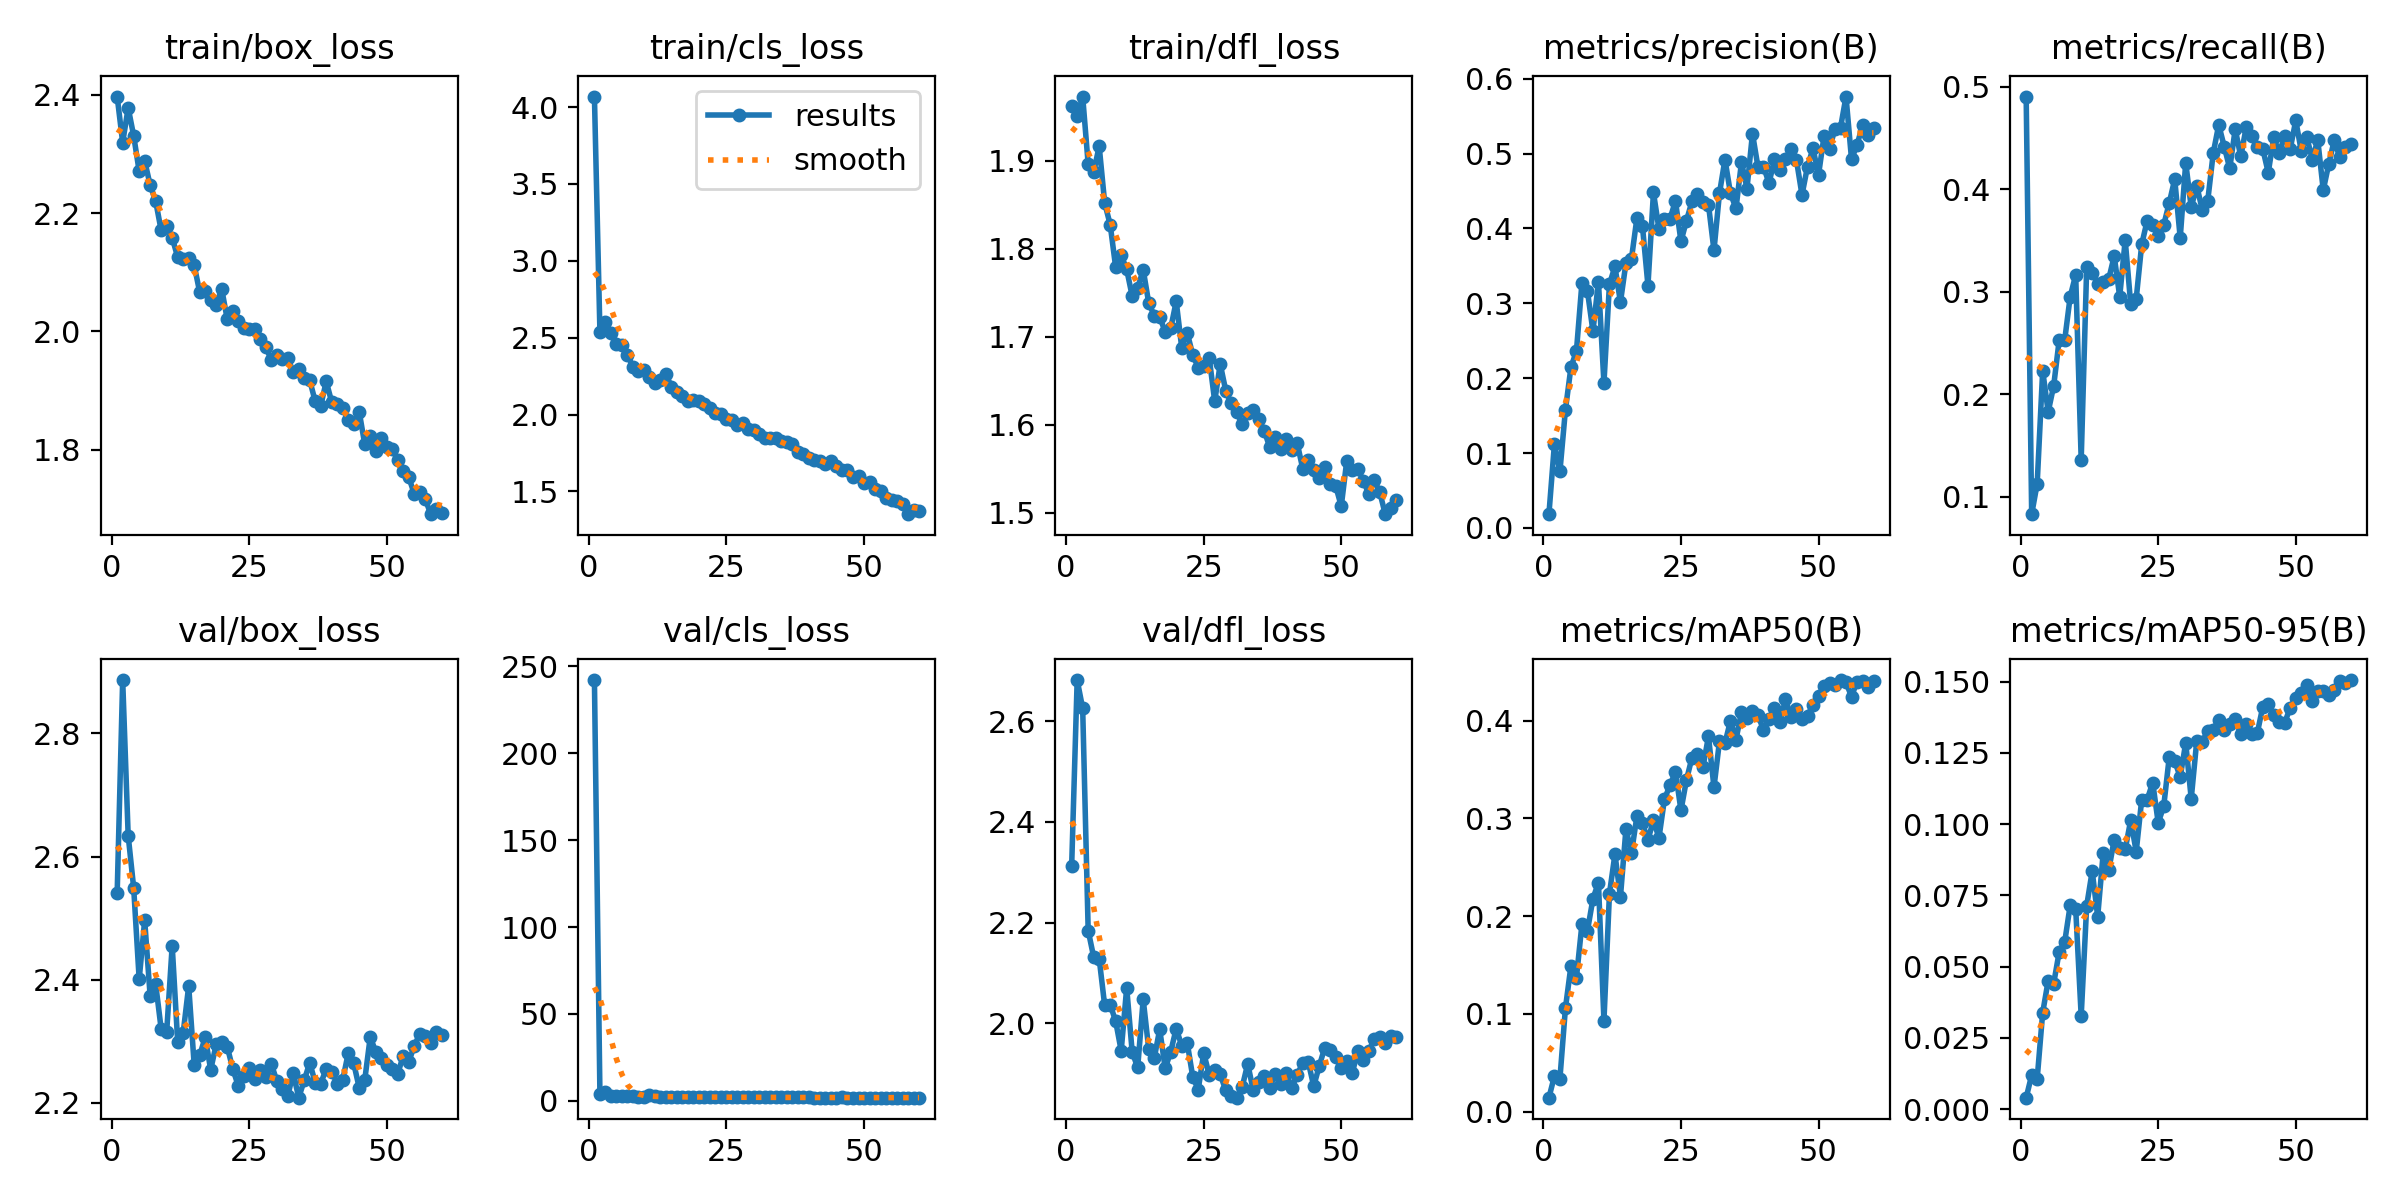

runs/detect/runs/pothole_v1/confusion_matrix.png


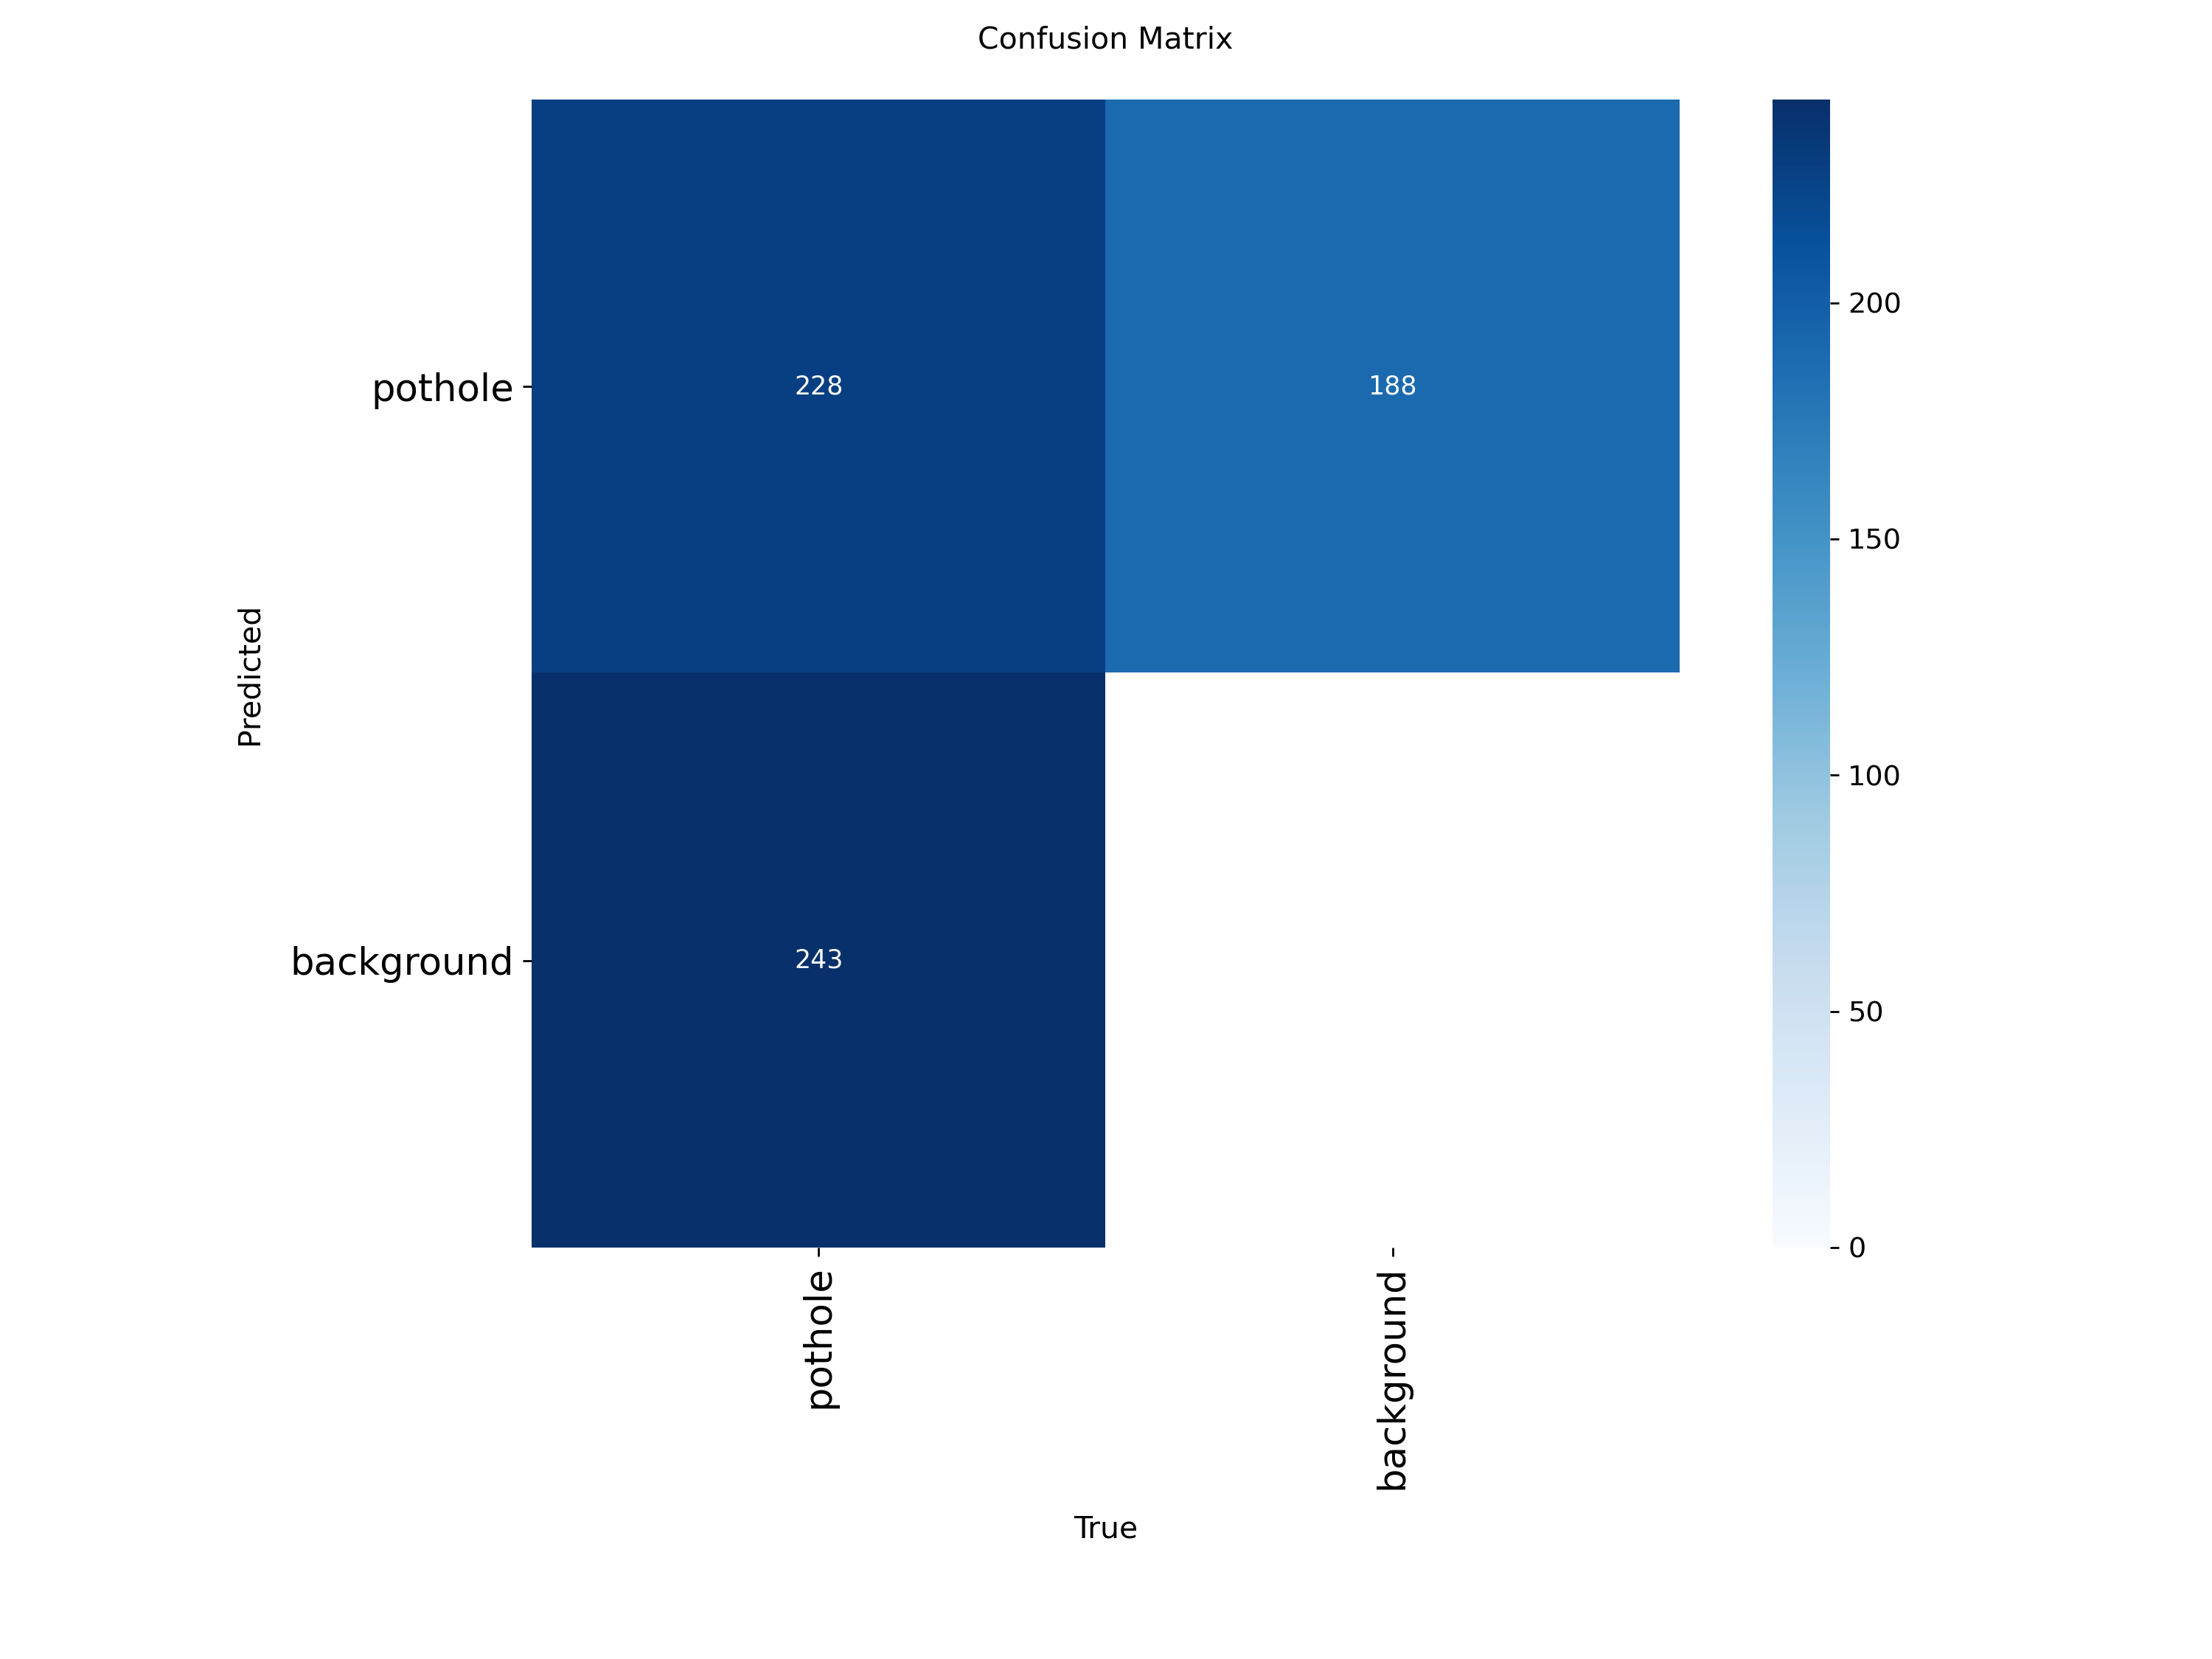

runs/detect/runs/pothole_v1/val_batch0_pred.jpg


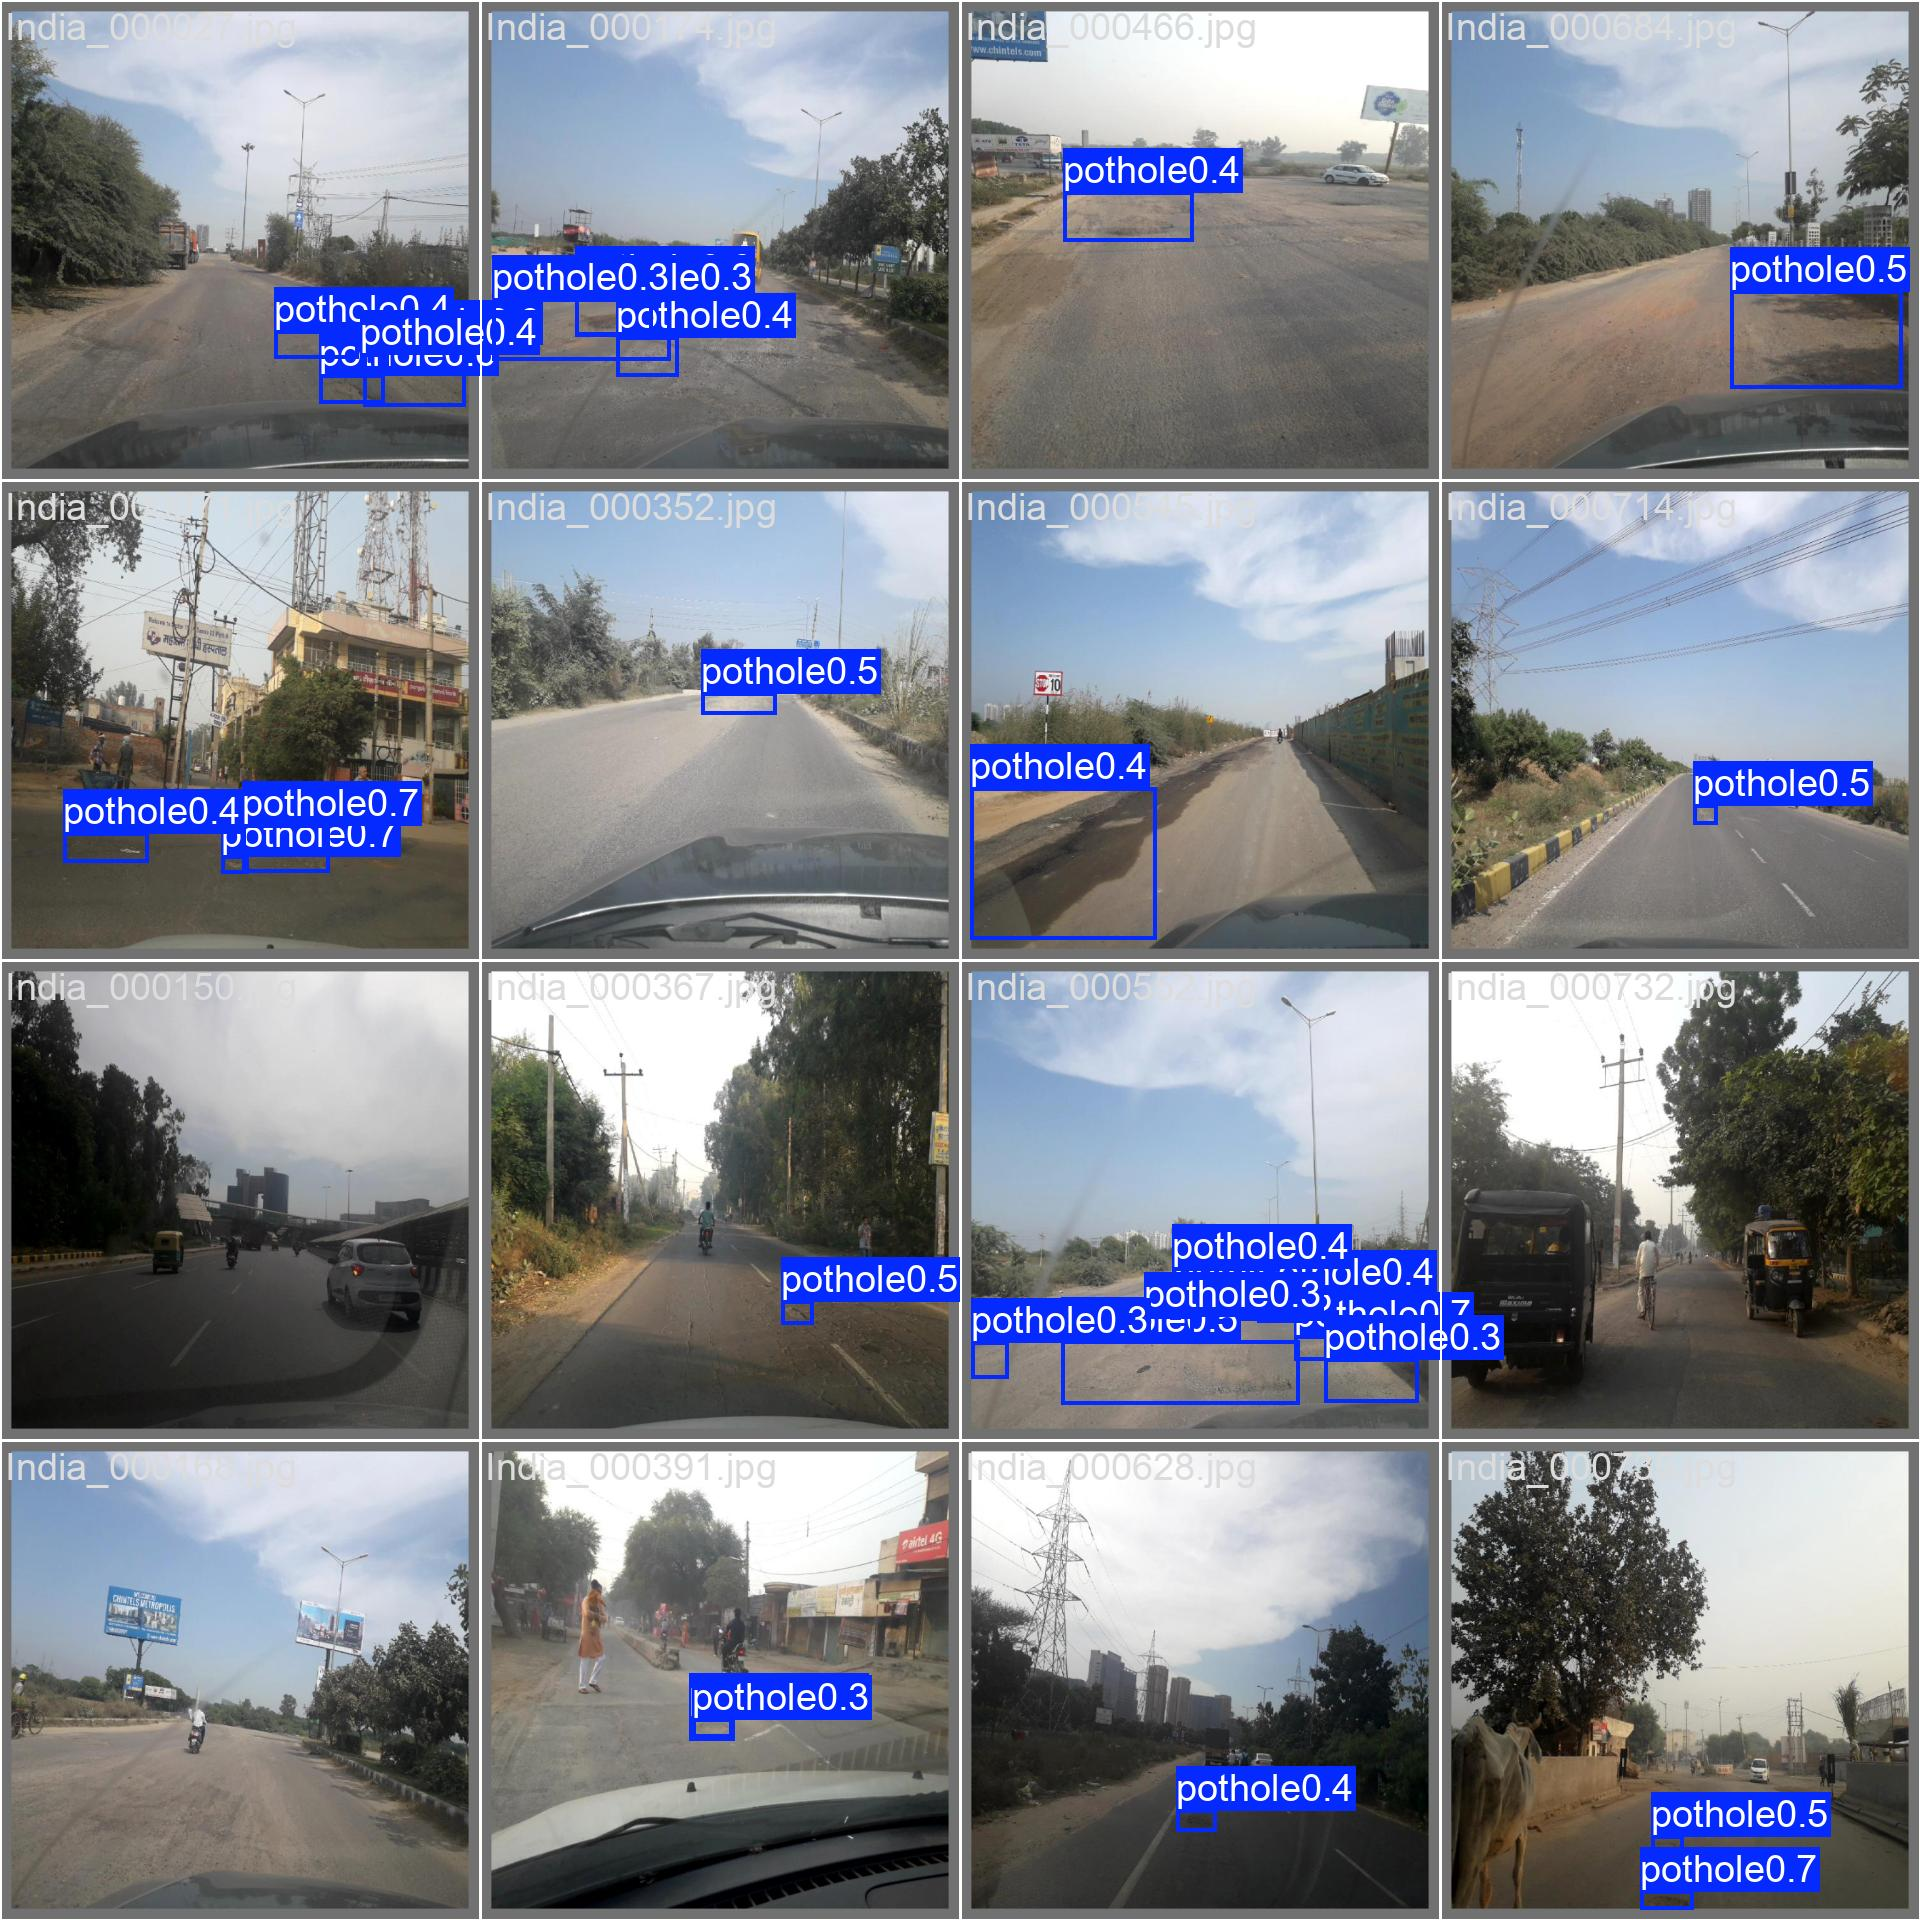

In [5]:
# Look at the training curves and a batch of validation predictions
from IPython.display import Image, display
import glob
runs = sorted(glob.glob('runs/**/pothole_v1*', recursive=True))
print("run dir:", runs[-1] if runs else "NOT FOUND - check the training log above")
run = runs[-1]
for f in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = f'{run}/{f}'
    if glob.glob(p):
        print(p); display(Image(p, width=900))


In [ ]:
# Drive fail hua - koi baat nahi, weights seedha laptop pe le aate hain
import glob, os, shutil
from google.colab import files

run = sorted(glob.glob('runs/**/pothole_v1*', recursive=True))[-1]
print("run dir:", run, "| best.pt mila:", os.path.exists('models/best.pt'))

open('val_metrics.py', 'w').write('''
from ultralytics import YOLO
m = YOLO('models/best.pt').val(data='data/yolo/data.yaml')
print(f'precision={m.box.mp:.3f} recall={m.box.mr:.3f} mAP50={m.box.map50:.3f} mAP50-95={m.box.map:.3f}')
''')
!python val_metrics.py

os.makedirs('artifacts', exist_ok=True)
shutil.copy2('models/best.pt', 'artifacts/best.pt')
for f in ['results.png', 'results.csv', 'confusion_matrix.png', 'val_batch0_pred.jpg', 'BoxPR_curve.png']:
    p = f'{run}/{f}'
    if os.path.exists(p):
        shutil.copy2(p, 'artifacts/')
!cd artifacts && zip -q -r ../pothole-artifacts.zip . && cd ..
print("zip ready:", round(os.path.getsize('pothole-artifacts.zip') / 1e6, 1), "MB")
files.download('pothole-artifacts.zip')

In [6]:
# Save weights + curves to Drive so they survive the session
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/pothole-models
!cp models/best.pt /content/drive/MyDrive/pothole-models/best.pt
!cp -r {run} /content/drive/MyDrive/pothole-models/
!ls -lh /content/drive/MyDrive/pothole-models

ValueError: mount failed

# Look at the training curves and a batch of validation predictions
from IPython.display import Image, display
import glob
runs = sorted(glob.glob('runs/**/pothole_v1*', recursive=True))
print("run dir:", runs[-1] if runs else "NOT FOUND - check the training log above")
run = runs[-1]
for f in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = f'{run}/{f}'
    if glob.glob(p):
        print(p); display(Image(p, width=900))
